In [43]:
# 1. Import Library

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import joblib

In [44]:
# 2. Load Dataset

df = pd.read_csv(
    "Students Social Media Addiction.csv"
)

df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [46]:
# 3. Data Understanding

# Ukuran Dataset
print(df.shape)

# Informasi Dataset
df.info()

# Statistik Dataset
df.describe()

# Missing Value
df.isnull().sum()

# Duplicate Data
df.duplicated().sum()

(705, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  


np.int64(0)

In [47]:
# 4. Feature Engineering

# Karena dataset tidak punya label risiko.

def kategori_risiko(score):

    if score <= 4:
        return "Rendah"

    elif score <= 7:
        return "Sedang"

    else:
        return "Tinggi"
df["Risk_Level"] = df[
    "Addicted_Score"
].apply(
    kategori_risiko
)

# Cek hasil:

df[
    ["Addicted_Score",
     "Risk_Level"]
].head()

,Addicted_Score,Risk_Level
0,8,Tinggi
1,3,Rendah
2,9,Tinggi
3,4,Rendah
4,7,Sedang


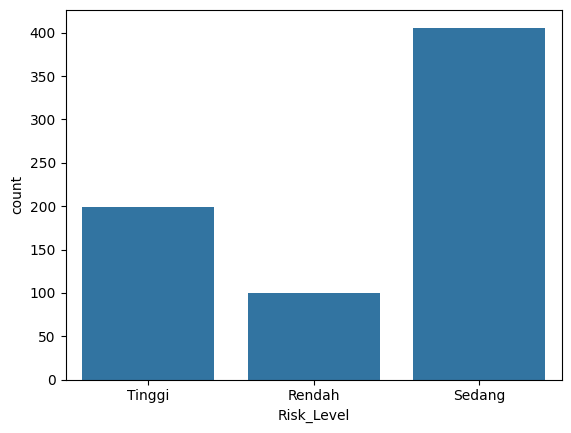

In [50]:
# 5. EDA (Exploratory Data Analysis)

# Distribusi Risiko
sns.countplot(
    x="Risk_Level",
    data=df
)

plt.show()

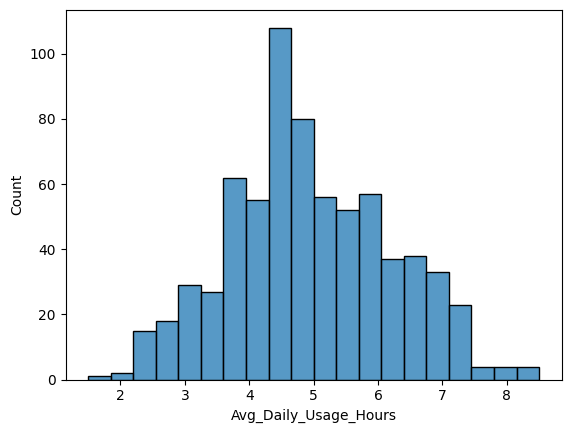

In [51]:
# Distribusi Durasi Penggunaan
sns.histplot(
    df["Avg_Daily_Usage_Hours"],
    bins=20
)

plt.show()


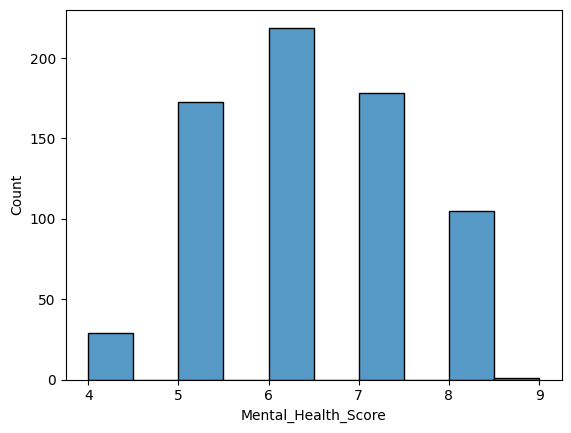

In [52]:
# Distribusi Mental Health
sns.histplot(
    df["Mental_Health_Score"],
    bins=10
)

plt.show()

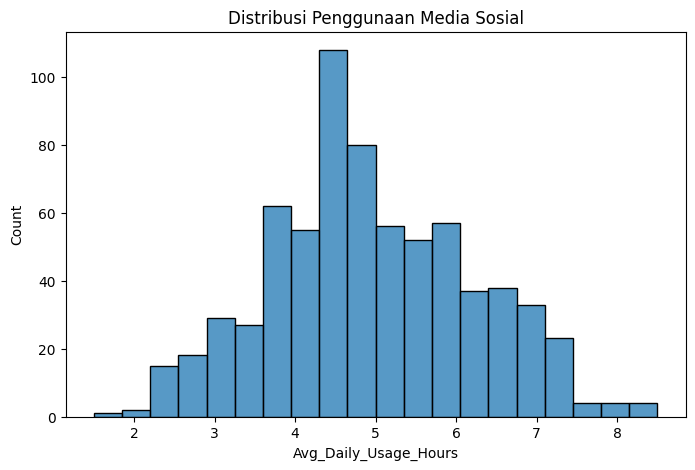

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(df["Avg_Daily_Usage_Hours"], bins=20)

plt.title("Distribusi Penggunaan Media Sosial")
plt.show()

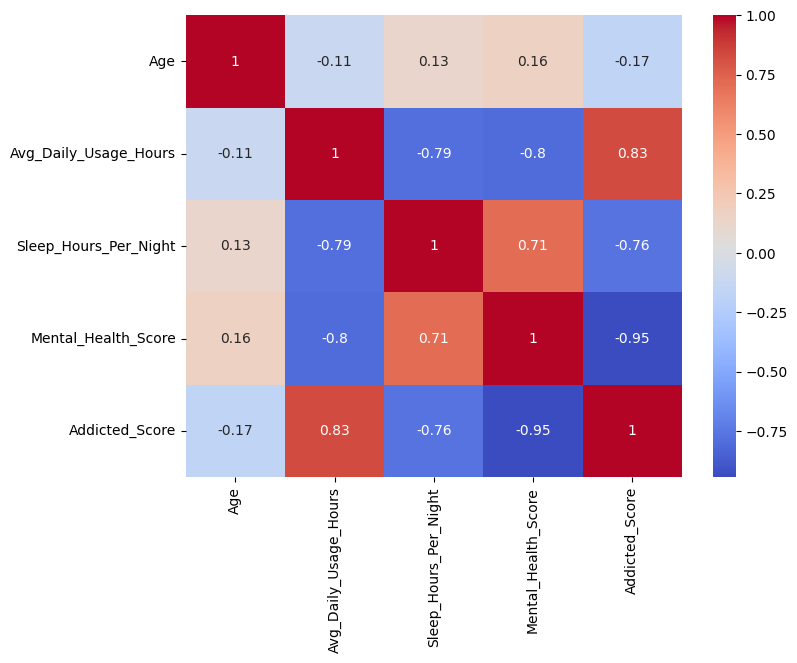

In [53]:
# Heatmap Korelasi
num_cols = [
    "Age",
    "Avg_Daily_Usage_Hours",
    "Sleep_Hours_Per_Night",
    "Mental_Health_Score",
    "Addicted_Score"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [56]:
# 6. Data Preparation
# Pisahkan Fitur dan Target
X = df.drop(
    [
        "Student_ID",
        "Addicted_Score",
        "Risk_Level"
    ],
    axis=1
)

y = df["Risk_Level"]

In [57]:
# Encoding
X = pd.get_dummies(
    X,
    drop_first=True
)

In [58]:
# 7. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [59]:
# 8. Modeling
# Model 1 — Decision Tree

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

dt_pred = dt.predict(
    X_test
)

dt_acc = accuracy_score(
    y_test,
    dt_pred
)

print(dt_acc)

0.9858156028368794


In [60]:
# Model 2 — Random Forest

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print(rf_acc)

0.9858156028368794


In [62]:
# Model 3 — Logistic Regression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(
    X_test
)

lr_acc = accuracy_score(
    y_test,
    lr_pred
)

print(lr_acc)

0.9787234042553191


In [63]:
# 9. Perbandingan Model
hasil = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest",
        "Logistic Regression"
    ],

    "Accuracy":[
        dt_acc,
        rf_acc,
        lr_acc
    ]
})

hasil

,Model,Accuracy
0,Decision Tree,0.985816
1,Random Forest,0.985816
2,Logistic Regression,0.978723


In [64]:
#10. Evaluasi Model Terbaik

print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

      Rendah       1.00      0.90      0.95        20
      Sedang       0.98      1.00      0.99        81
      Tinggi       1.00      1.00      1.00        40

    accuracy                           0.99       141
   macro avg       0.99      0.97      0.98       141
weighted avg       0.99      0.99      0.99       141



In [66]:
#12. Feature Importance
importance = pd.DataFrame({

    "Feature":
    X.columns,

    "Importance":
    rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
4,Conflicts_Over_Social_Media,0.278295
3,Mental_Health_Score,0.193981
1,Avg_Daily_Usage_Hours,0.109737
2,Sleep_Hours_Per_Night,0.102536
128,Affects_Academic_Performance_Yes,0.036326
53,Country_Japan,0.019421
0,Age,0.016921
120,Most_Used_Platform_LinkedIn,0.015452
100,Country_Switzerland,0.014665
129,Relationship_Status_In Relationship,0.014253


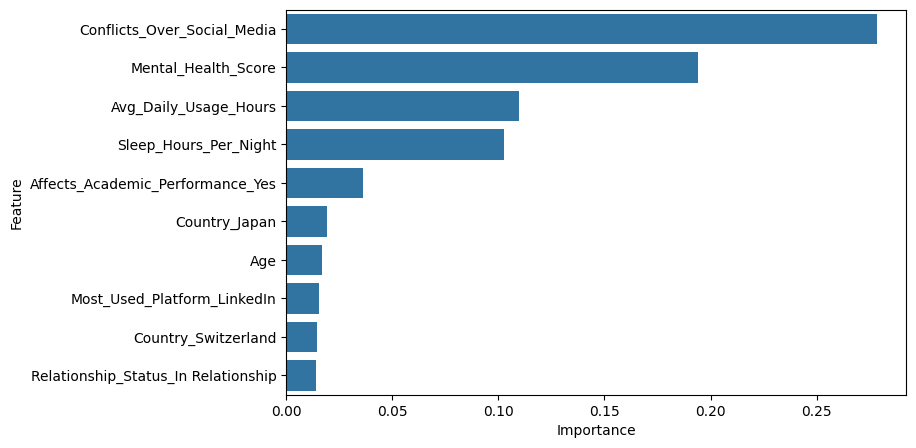

In [68]:
#Visualisasi:

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.show()

In [69]:
# 13. Save Model
joblib.dump(
    rf,
    "scrollsense_model.pkl"
)

['scrollsense_model.pkl']